<a href="https://colab.research.google.com/github/mannuh0051/Projects-/blob/main/student%20enrollment%20predictive%20model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**studdent enrollment prediction**

##*testing the file *

In [4]:
import pandas as pd
df = pd.read_csv("/Studentdet.csv")
print("dataset loaded successfully")
print(df.head())

dataset loaded successfully
   id  age gender  study_time  absences  G1  G2  G3 parent_education internet  \
0   1   17      F           2         3  12  13  14             high      yes   
1   2   18      M           1        10   8   9  10           medium       no   
2   3   16      F           3         0  14  15  15           higher      yes   
3   4   17      M           2         5  10  11  12             high      yes   
4   5   16      F           1         7   6   7   8           medium       no   

  extra_support  enrolled  
0            no         1  
1           yes         1  
2            no         1  
3           yes         1  
4            no         0  


### *split features and target where the target column is enrollment*

In [5]:
x=df.drop("enrolled", axis=1)
y=df["enrolled"]

###*detect numeric and cartegorical data.*

In [6]:
numeric_features=x.select_dtypes(include=["int64", "float64"]).columns
categorical_features=x.select_dtypes(include=["object"]).columns

##**preprocesssing**

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

###train test and splitting




In [14]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

##Model : random forest since it is suitable for our small datasets


.....Classification Report.....
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         9

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



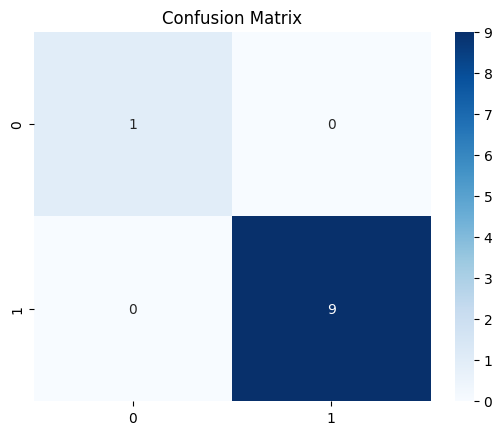

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)

print("\n.....Classification Report.....")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()
